# **YOLOV3 plots explanation**

In [62]:
from PIL import Image
from pathlib import Path

import os
import sys
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

path = Path.cwd()
while not (path / "computer_vision").exists():
    path = path.parent

sys.path.append(str(path))

datasets_path = "/home/otokonokage/Documents/github/dataset/computer_vision/"

In [63]:
from computer_vision.datasets import vocdetection

dataset_path, annotations, weights, num_classes, categories, dataset_name, dataset_box_format, mode, dataset_normalized = vocdetection(datasets_path, "train", year="2012")
reversed_categories = dict([(id, label) for label, id in categories.items()])

train pascalvoc2012: 100%|██████████| 17125/17125 [00:00<00:00, 17514.60it/s]


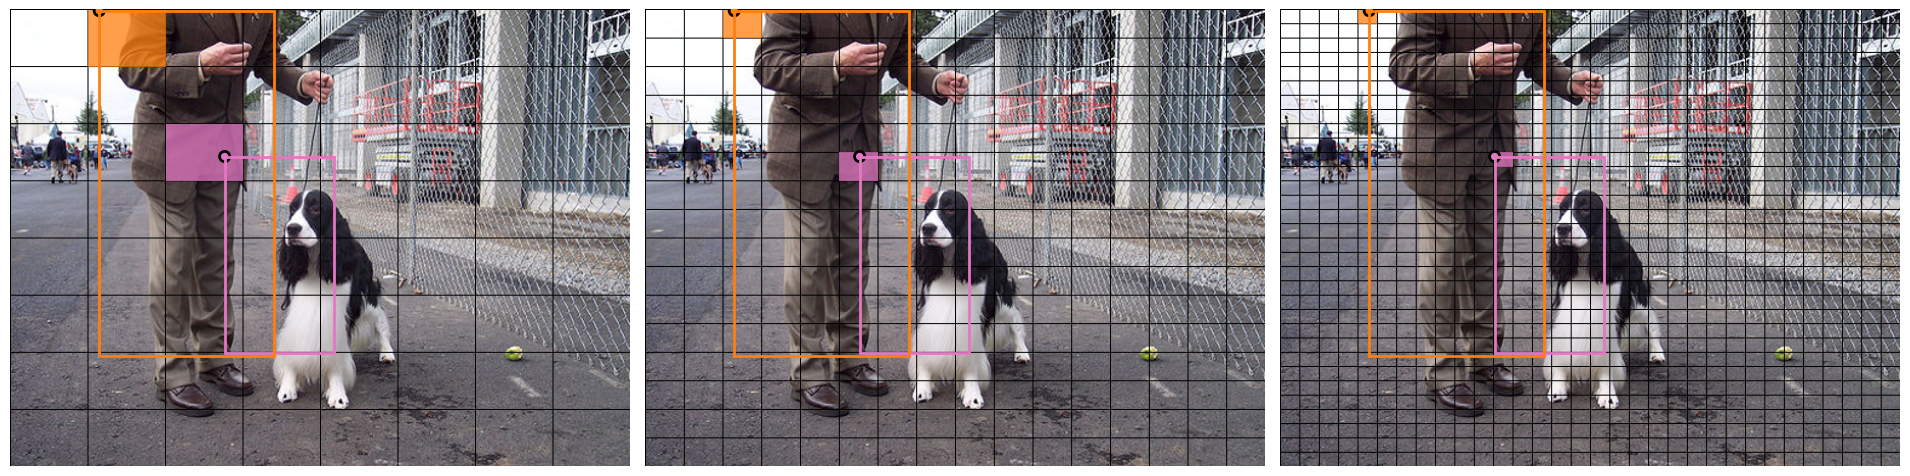

In [ ]:
cmap = plt.get_cmap('tab20')

colors = dict([(category, cmap(i / num_classes)) for i, category in enumerate(reversed_categories)])

fig, ax = plt.subplots(1, 3, figsize=(19.2, 10.8))

image = np.array(Image.open(os.path.join(dataset_path, "2008_001182.jpg"), "r").resize((608, 448)))
H, W, _ = image.shape

for col, s in enumerate([8, 16, 32]):
    dw, dh = H // s, W // s
    grid_color = [0,0,0]

    img = image.copy()
    img[:,::dh,:] = grid_color
    img[::dw,:,:] = grid_color
    ax[col].imshow(img)
    ax[col].axis("off")

    for bbox in annotations["bboxes"]["2008_001182"]:
        label = bbox[0]
        bbox = bbox[1:]
        x, y = math.floor((bbox[0] / W) * s) * (W / s), math.floor((bbox[1] / H) * s) * (H / s)
        rect = patches.Rectangle((x, y), W / s, H / s, linewidth=0, facecolor=colors[label], edgecolor=colors[label], alpha=0.75)
        ax[col].add_patch(rect)

        circle = patches.Circle((bbox[0], bbox[1]), radius=5, linewidth=2, edgecolor="black", facecolor=colors[label])
        ax[col].add_patch(circle)
        rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1], linewidth=2, edgecolor=colors[label], facecolor='none', alpha=1)
        ax[col].add_patch(rect)
    
fig.tight_layout()
plt.savefig(os.path.join(os.path.dirname(""), "plots", f"yolov3_explanation"), bbox_inches="tight")
plt.show()